# Demand Time Series Exploration
**Author:** Anuj Saini  
**Date:** July 14, 2026

This notebook explores the historical demand data from the e-commerce database. We aggregate transaction-level order items to analyze weekly demand patterns, both overall and across individual product categories. We aim to understand the shape of the demand (trend, seasonality, volatility) and evaluate the feasibility of forecasting.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Database Connection
host = "aws-0-ap-south-1.pooler.supabase.com"
port = "5432"
database = "postgres"
username = "ecom_ro_user.imnzftquwjuxcwpeufwp"
password = "work-experience-read-only"
schema = "ecom"

conn_url = f"postgresql://{username}:{password}@{host}:{port}/{database}"
engine = create_engine(conn_url)
print("Connected to database successfully!")

Connected to database successfully!


In [2]:
# Load orders and order items data
query = """
    SELECT 
        o.order_id,
        o.created_at,
        o.status,
        oi.variant_id,
        oi.qty,
        oi.unit_price,
        oi.line_total,
        c.category_name,
        p.product_name
    FROM ecom.orders o
    JOIN ecom.order_items oi ON o.order_id = oi.order_id
    JOIN ecom.product_variants pv ON oi.variant_id = pv.variant_id
    JOIN ecom.products p ON pv.product_id = p.product_id
    JOIN ecom.categories c ON p.category_id = c.category_id;
"""

df = pd.read_sql(query, engine)
df['created_at'] = pd.to_datetime(df['created_at'])
print(f"Loaded {len(df)} order items across {df['order_id'].nunique()} unique orders.")
print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}")

Loaded 81806 order items across 40000 unique orders.
Date range: 2026-03-16 00:13:57+00:00 to 2026-06-14 23:28:40+00:00


In [3]:
# Aggregate weekly demand
# We define week_start as the Monday-based start of the week.
df['week_start'] = df['created_at'].dt.to_period('W').dt.start_time

# Total weekly demand
weekly_total = df.groupby('week_start')['qty'].sum().reset_index()

# Weekly demand by category
weekly_cat = df.groupby(['week_start', 'category_name'])['qty'].sum().unstack(fill_value=0)

print("Weekly total demand:")
print(weekly_total)

Weekly total demand:
   week_start    qty
0  2026-03-16  11640
1  2026-03-23  11138
2  2026-03-30  13653
3  2026-04-06  14006
4  2026-04-13   9923
5  2026-04-20   7304
6  2026-04-27   6688
7  2026-05-04   6350
8  2026-05-11   5564
9  2026-05-18   6688
10 2026-05-25   5828
11 2026-06-01   4121
12 2026-06-08   3302


/tmp/ipykernel_234696/2631900725.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week_start'] = df['created_at'].dt.to_period('W').dt.start_time


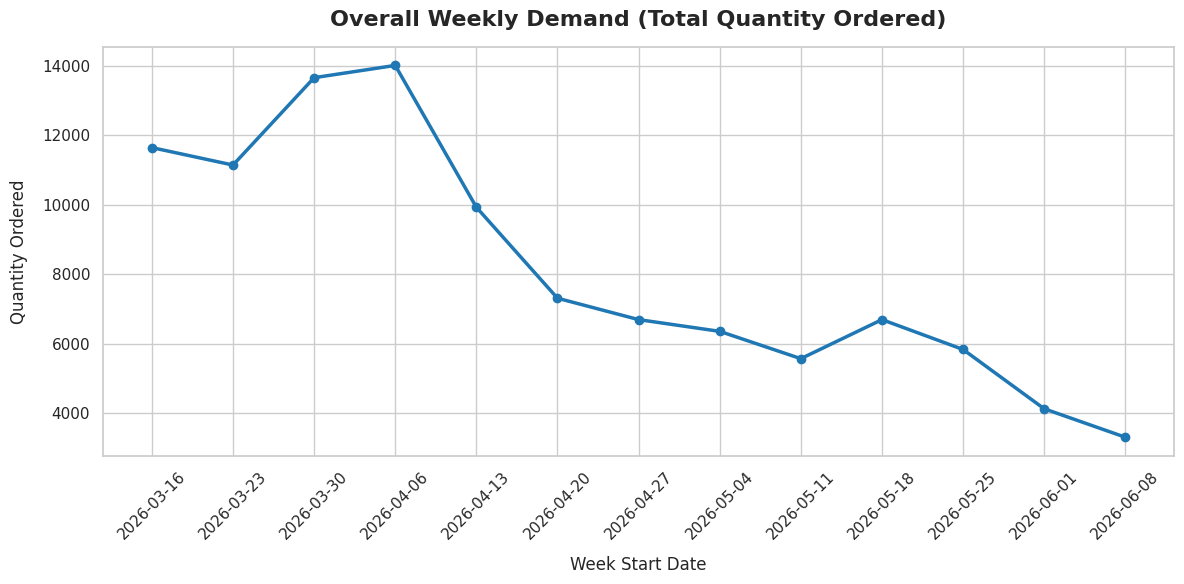

In [4]:
# Plot Overall Weekly Demand
plt.figure(figsize=(12, 6))
plt.plot(weekly_total['week_start'], weekly_total['qty'], marker='o', color='#1f77b4', linewidth=2.5)
plt.title('Overall Weekly Demand (Total Quantity Ordered)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Week Start Date', fontsize=12, labelpad=10)
plt.ylabel('Quantity Ordered', fontsize=12, labelpad=10)
plt.xticks(weekly_total['week_start'], rotation=45)
plt.tight_layout()
plt.savefig('overall_demand.png', dpi=150)
plt.show()

### Shape of Overall Demand
- **Trend:** There is a very strong, consistent downward trend after a peak in early April. Total quantity ordered starts around 11,640 units in the week of 2026-03-16, peaks at 14,006 units in the week of 2026-04-06, and then steadily declines to 3,302 units in the final week of 2026-06-08. This is a massive ~76.4% drop from the peak to the last week.
- **Seasonality:** With only 13 weeks of data (exactly 3 months), we cannot observe or learn yearly seasonal patterns (such as summer peaks, holiday spikes, or back-to-school trends). Any cyclical pattern we see could just be short-term fluctuations.
- **Volatility:** Demand is highly volatile in the first few weeks (spiking from 11k to 14k, then dropping to 9.9k), but stabilizes into a smoother, steady decline from mid-April onwards.

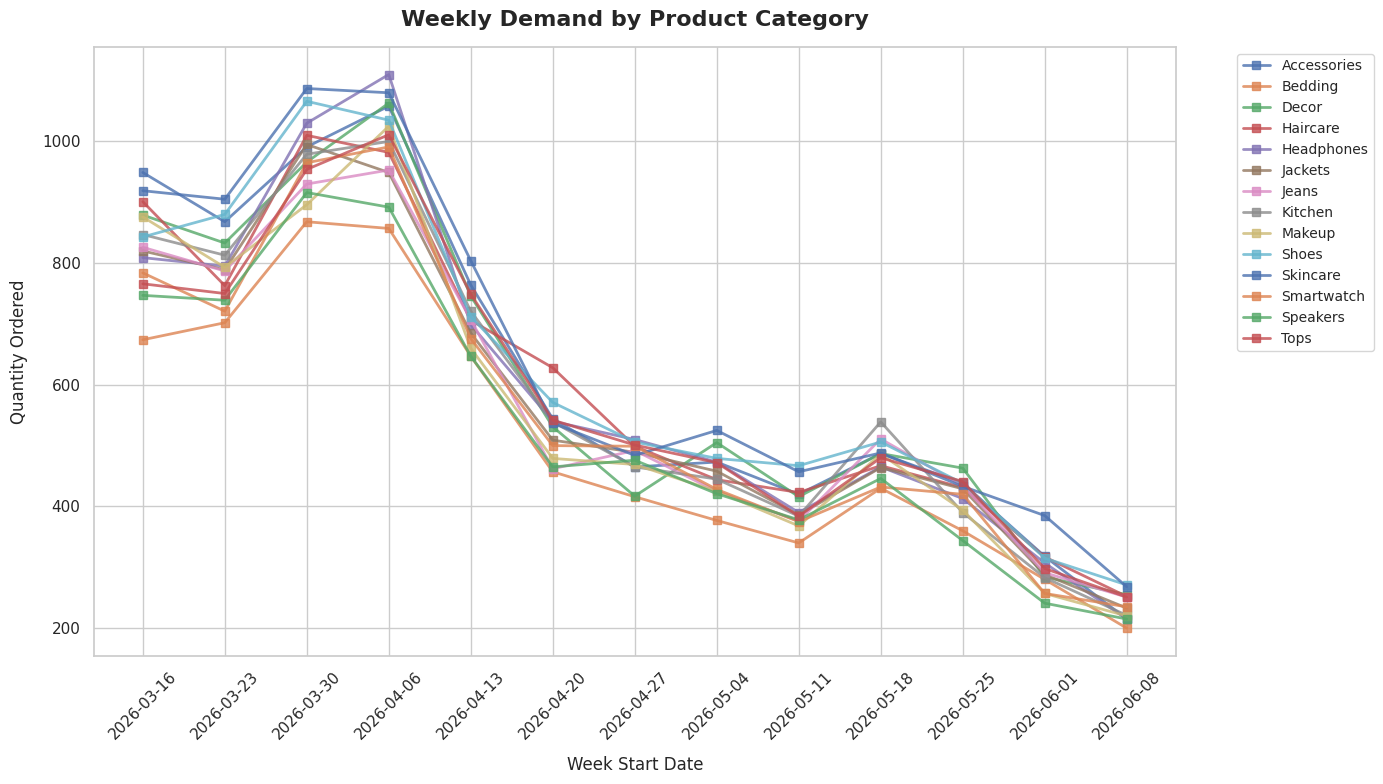

In [5]:
# Plot Weekly Demand by Category
plt.figure(figsize=(14, 8))
for col in weekly_cat.columns:
    plt.plot(weekly_cat.index, weekly_cat[col], marker='s', label=col, alpha=0.8, linewidth=2)

plt.title('Weekly Demand by Product Category', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Week Start Date', fontsize=12, labelpad=10)
plt.ylabel('Quantity Ordered', fontsize=12, labelpad=10)
plt.xticks(weekly_cat.index, rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('category_demand.png', dpi=150)
plt.show()

In [6]:
# Calculate percentage drop from peak to last week for each category
peak_week = pd.Timestamp('2026-04-06')
last_week = pd.Timestamp('2026-06-08')

drop_df = pd.DataFrame(columns=['Peak Qty', 'Last Week Qty', 'Pct Change'])
for col in weekly_cat.columns:
    peak_val = weekly_cat.loc[peak_week, col]
    last_val = weekly_cat.loc[last_week, col]
    pct_change = ((last_val - peak_val) / peak_val) * 100
    drop_df.loc[col] = [peak_val, last_val, pct_change]

drop_df = drop_df.sort_values(by='Pct Change')
print("Percentage change from peak week to last week by category:")
print(drop_df.round(1))

Percentage change from peak week to last week by category:
             Peak Qty  Last Week Qty  Pct Change
Headphones     1110.0          215.0       -80.6
Accessories    1058.0          215.0       -79.7
Makeup         1025.0          220.0       -78.5
Kitchen        1000.0          221.0       -77.9
Bedding         857.0          200.0       -76.7
Smartwatch      991.0          235.0       -76.3
Decor          1063.0          255.0       -76.0
Speakers        892.0          215.0       -75.9
Jackets         949.0          233.0       -75.4
Skincare       1080.0          268.0       -75.2
Tops           1011.0          251.0       -75.2
Haircare        982.0          252.0       -74.3
Shoes          1035.0          271.0       -73.8
Jeans           953.0          251.0       -73.7


### Shape of Category-Level Demand
- **Uniformity:** The decline is extremely uniform across all 14 categories. The drop from the peak week (2026-04-06) to the last week (2026-06-08) ranges between **-73.7%** (Jeans) and **-80.6%** (Headphones).
- **Implication:** The fact that all categories decay at nearly the identical rate suggests a global, system-wide driver rather than shifts in customer product preferences. Possible explanations include:
  1. A sharp reduction in overall marketing/acquisition spend.
  2. Post-launch decay (e.g., if the store launched in March with huge promotional campaigns that have since ended).
  3. A technical issue with checkout or order tracking.
  4. Decaying cohorts if the traffic was heavily driven by a single initial cohort.
- **Category Volume:** Skincare (8,372 units), Shoes (8,089 units), and Accessories (7,990 units) are the highest volume categories, while Bedding (6,608 units) is the lowest. Despite the volume differences, their trajectories are almost perfectly correlated.

### Constraints & Challenges for ML Forecasting
1. **Short Historical Window:** We have only 13 weeks of data. Standard time-series models (like SARIMA or Prophet) cannot learn yearly seasonality (e.g. winter vs. summer trends, Black Friday).
2. **Systemic Trend Shift:** The steep and continuous drop in demand makes it hard to distinguish between a permanent decline in the business, a temporary post-promotion slump, or a seasonal pattern.
3. **Data Sparsity at SKU Level:** With 12,077 unique variants and only 106,205 total units, the transaction volume is extremely sparse at the variant (SKU) level. Any model trying to forecast at the individual SKU level will suffer from high variance and massive zero-inflation.

### Precise Problem Framing
We translate the operations director's request into the following concrete machine learning task:

**"Predict weekly demand (total quantity ordered) at the product category level for a 4-week horizon (weeks $t+1$ to $t+4$), evaluated by Weighted Mean Absolute Percentage Error (WMAPE)."**